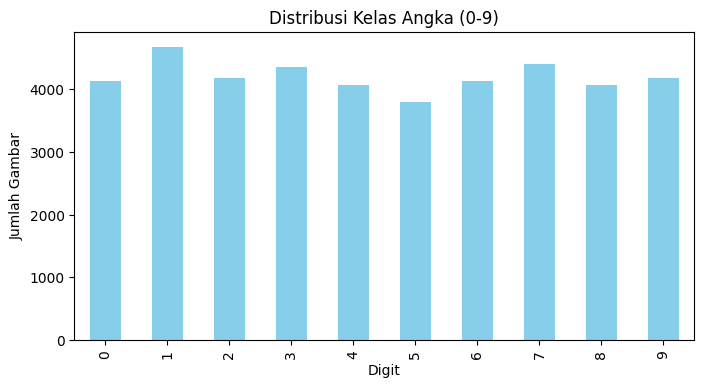

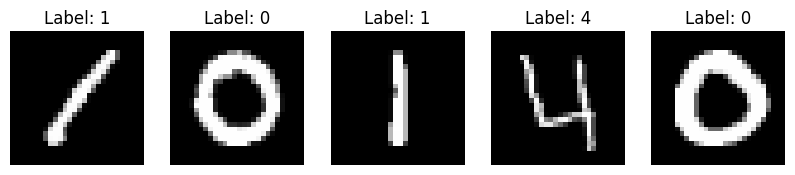

Shape Data Training: (33600, 784)
Shape Data Testing: (8400, 784)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

# Memuat dataset (Pastikan ini file train.csv dari dataset MNIST Kaggle)
df_mnist = pd.read_csv('train-kasus2.csv')

# Memisahkan label (target) dan fitur (pixel)
y_mnist = df_mnist['label']
X_mnist = df_mnist.drop('label', axis=1)

# --- EKSPLORASI DATA (EDA) ---

# Grafik 1: Menampilkan distribusi kelas
plt.figure(figsize=(8, 4))
df_mnist['label'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribusi Kelas Angka (0-9)')
plt.xlabel('Digit')
plt.ylabel('Jumlah Gambar')
plt.show() # Tampilkan grafik pertama dan tutup kanvasnya

# Grafik 2: Menampilkan 5 contoh gambar angka
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Mereshape data 1D (784 pixel) menjadi 2D (28x28 pixel) untuk ditampilkan
    img = X_mnist.iloc[i].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {y_mnist.iloc[i]}")
    plt.axis('off')
plt.show()

# --- PEMBAGIAN DATA ---
# Split data menjadi Train (80%) dan Test (20%).
# HARUS KONSISTEN dipakai untuk SVM, Random Forest, dan CNN nanti!
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mnist, y_mnist, test_size=0.2, random_state=42, stratify=y_mnist
)

print(f"Shape Data Training: {X_train_m.shape}")
print(f"Shape Data Testing: {X_test_m.shape}")

Mengekstrak fitur HOG untuk data training (Tunggu sebentar)...
Mengekstrak fitur HOG untuk data testing...

--- Training SVM dengan HOG ---
Waktu Training HOG+SVM: 14.34 detik
Akurasi HOG+SVM: 0.9704


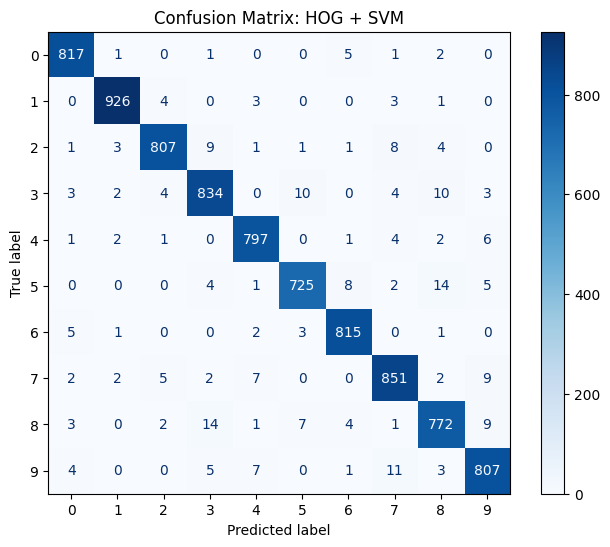

In [3]:
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. FUNGSI EKSTRAKSI FITUR HOG
def extract_hog_features(X):
    hog_features = []
    # Loop melalui setiap baris gambar
    for i in range(len(X)):
        # Reshape ke 28x28
        img = X.iloc[i].values.reshape(28, 28)
        # Ekstraksi HOG (parameter disesuaikan agar tidak terlalu berat)
        features = hog(img, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=False)
        hog_features.append(features)
    return np.array(hog_features)

print("Mengekstrak fitur HOG untuk data training (Tunggu sebentar)...")
X_train_hog = extract_hog_features(X_train_m)
print("Mengekstrak fitur HOG untuk data testing...")
X_test_hog = extract_hog_features(X_test_m)

# 2. TRAINING SVM PADA FITUR HOG
print("\n--- Training SVM dengan HOG ---")
start_time_svm = time.time()

# Menggunakan SVC (Support Vector Classification)
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_model.fit(X_train_hog, y_train_m)

time_svm = time.time() - start_time_svm

# 3. PREDIKSI & EVALUASI
y_pred_svm = svm_model.predict(X_test_hog)
acc_svm = accuracy_score(y_test_m, y_pred_svm)

print(f"Waktu Training HOG+SVM: {time_svm:.2f} detik")
print(f"Akurasi HOG+SVM: {acc_svm:.4f}")

# Menampilkan Confusion Matrix
cm_svm = confusion_matrix(y_test_m, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_svm.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: HOG + SVM')
plt.show()

--- Ekstraksi Fitur PCA & Training Random Forest ---
Dimensi awal: 784 pixel. Dimensi setelah PCA (95% varians): 153 komponen.
Waktu Training PCA+RF: 78.94 detik
Akurasi PCA+RF: 0.9413


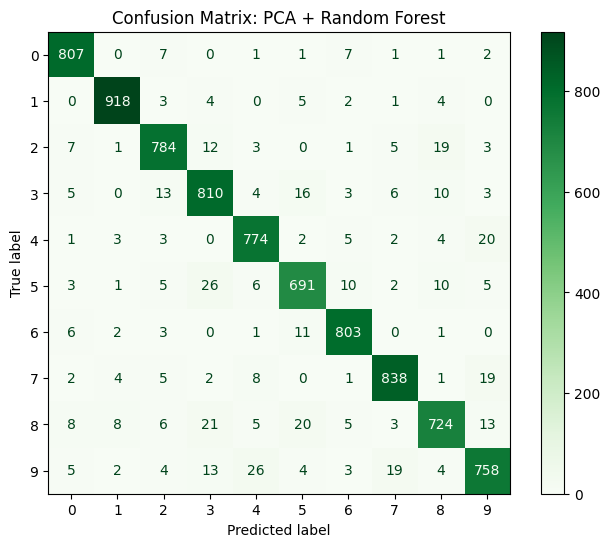

In [4]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

print("--- Ekstraksi Fitur PCA & Training Random Forest ---")
start_time_rf_m = time.time()

# 1. EKSTRAKSI FITUR PCA
# Pertahankan 95% varians dari data asli untuk mereduksi dimensi
pca = PCA(n_components=0.95, random_state=42)

# Normalisasi data pixel (0-255) ke (0-1) sangat dianjurkan sebelum PCA
X_train_scaled = X_train_m / 255.0
X_test_scaled = X_test_m / 255.0

# Fit PCA di data train, lalu transform ke train dan test
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Dimensi awal: 784 pixel. Dimensi setelah PCA (95% varians): {X_train_pca.shape[1]} komponen.")

# 2. TRAINING RANDOM FOREST PADA FITUR PCA
rf_model_m = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_m.fit(X_train_pca, y_train_m)

time_rf_m = time.time() - start_time_rf_m

# 3. PREDIKSI & EVALUASI
y_pred_rf_m = rf_model_m.predict(X_test_pca)
acc_rf_m = accuracy_score(y_test_m, y_pred_rf_m)

print(f"Waktu Training PCA+RF: {time_rf_m:.2f} detik")
print(f"Akurasi PCA+RF: {acc_rf_m:.4f}")

# Menampilkan Confusion Matrix
cm_rf = confusion_matrix(y_test_m, y_pred_rf_m)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model_m.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(ax=ax, cmap='Greens')
plt.title('Confusion Matrix: PCA + Random Forest')
plt.show()

--- Persiapan Data untuk CNN ---
Shape Input CNN: (33600, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training CNN (Membutuhkan GPU) ---
Epoch 1/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.8759 - loss: 0.3918 - val_accuracy: 0.9705 - val_loss: 0.0931
Epoch 2/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9605 - loss: 0.1231 - val_accuracy: 0.9802 - val_loss: 0.0653
Epoch 3/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9722 - loss: 0.0927 - val_accuracy: 0.9824 - val_loss: 0.0564
Epoch 4/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.9765 - loss: 0.0743 - val_accuracy: 0.9856 - val_loss: 0.0456
Epoch 5/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9809 - loss: 0.0636 - val_accuracy: 0.9862 - val_loss: 0.0450
Epoch 6/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9819 - loss: 0.0567 - val_accuracy: 0.9871 - val_loss: 0.0427
Epoch 7/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9836 - loss: 0.0534 - val_accuracy: 0.9881 - val_loss: 0.0400
Epoch 8/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/s

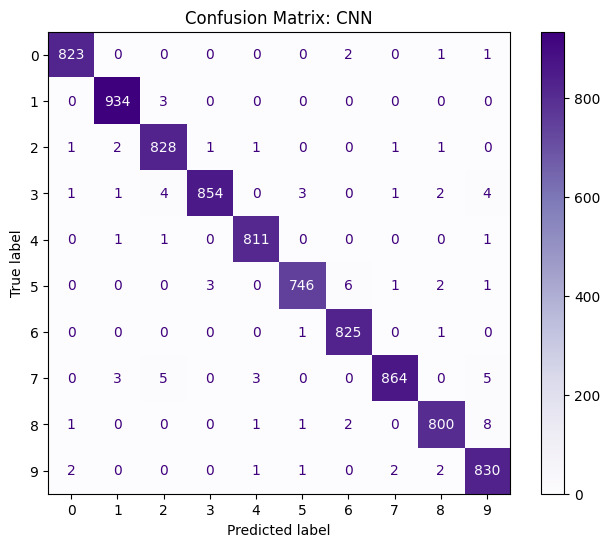

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("--- Persiapan Data untuk CNN ---")
# CNN membutuhkan input berbentuk 3D: (Tinggi, Lebar, Channel Warna)
# MNIST adalah gambar grayscale, jadi channel warnanya 1.
# Membagi dengan 255.0 untuk normalisasi nilai pixel (0-1).
X_train_cnn = X_train_m.values.reshape(-1, 28, 28, 1) / 255.0
X_test_cnn = X_test_m.values.reshape(-1, 28, 28, 1) / 255.0

print(f"Shape Input CNN: {X_train_cnn.shape}")

# 1. Membangun Arsitektur CNN Sederhana
model_cnn = Sequential([
    # Layer Konvolusi 1: Mengekstrak fitur dasar (tepi, garis)
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)), # Mengurangi dimensi gambar

    # Layer Konvolusi 2: Mengekstrak fitur yang lebih kompleks
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25), # Regularisasi untuk mencegah overfitting

    # Meratakan (flatten) output dari 2D menjadi 1D untuk masuk ke MLP
    Flatten(),

    # Fully Connected Layer (MLP)
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer (10 Kelas untuk angka 0-9)
    Dense(10, activation='softmax')
])

# 2. Kompilasi Model
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy', # Cocok untuk label integer (bukan one-hot)
                  metrics=['accuracy'])

# Early stopping untuk menghentikan training jika val_loss tidak membaik
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n--- Training CNN (Membutuhkan GPU) ---")
start_time_cnn = time.time()

# 3. Proses Training
history_cnn = model_cnn.fit(X_train_cnn, y_train_m,
                            epochs=20,
                            batch_size=64,
                            validation_split=0.2,
                            callbacks=[early_stop_cnn],
                            verbose=1)

time_cnn = time.time() - start_time_cnn

# 4. Prediksi dan Evaluasi
print("\n--- Evaluasi CNN pada Test Set ---")
# CNN menghasilkan probabilitas untuk 10 kelas, kita ambil index dengan probabilitas tertinggi
y_pred_cnn_prob = model_cnn.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)

acc_cnn = accuracy_score(y_test_m, y_pred_cnn)

print(f"Waktu Training CNN: {time_cnn:.2f} detik")
print(f"Akurasi Test CNN: {acc_cnn:.4f}")
print(f"Total Parameter: {model_cnn.count_params()}")

# 5. Menampilkan Confusion Matrix CNN
cm_cnn = confusion_matrix(y_test_m, y_pred_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=[str(i) for i in range(10)])
fig, ax = plt.subplots(figsize=(8, 6))
disp_cnn.plot(ax=ax, cmap='Purples')
plt.title('Confusion Matrix: CNN')
plt.show()

--- TABEL PERBANDINGAN KASUS 2 (MNIST) ---


,Model,Test Accuracy,Training Time (s)
0,HOG + SVM,0.970357,14.341292
1,PCA + Random Forest,0.941310,78.935153
2,CNN (Deep Learning),0.989881,291.606576



Membuat visualisasi Analisis Error...


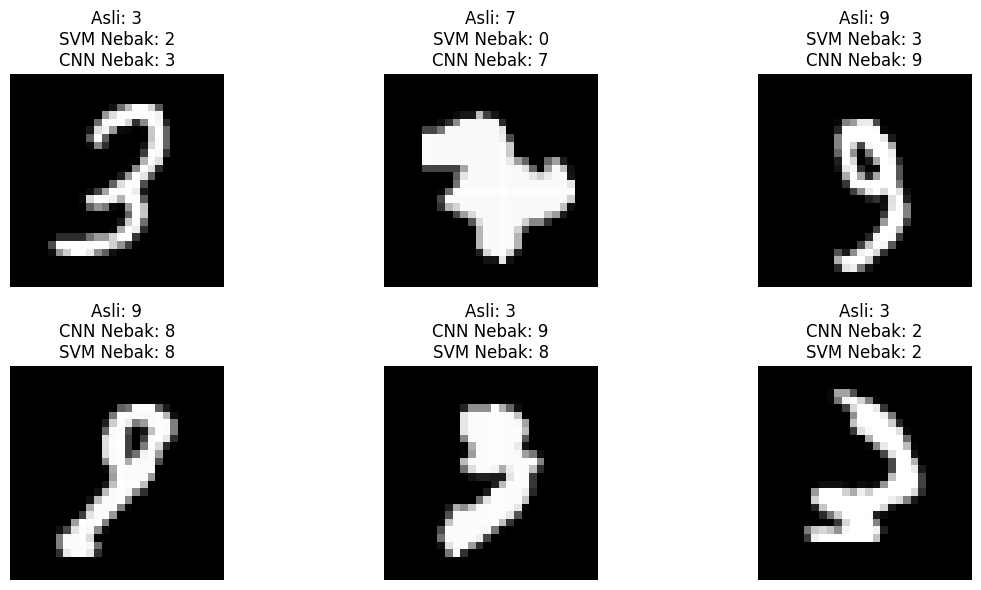

In [6]:
# 1. Membuat Tabel Perbandingan Kasus 2
results_mnist = pd.DataFrame({
    'Model': ['HOG + SVM', 'PCA + Random Forest', 'CNN (Deep Learning)'],
    'Test Accuracy': [acc_svm, acc_rf_m, acc_cnn],
    'Training Time (s)': [time_svm, time_rf_m, time_cnn]
})

print("--- TABEL PERBANDINGAN KASUS 2 (MNIST) ---")
display(results_mnist)

# 2. Analisis Error: Mencari Gambar yang Salah Diprediksi
# Mengubah y_test_m menjadi array numpy agar mudah dibandingkan indexnya
y_test_array = y_test_m.values

# A. Mencari index di mana HOG+SVM salah, tapi CNN benar
svm_wrong_cnn_right = np.where((y_test_array != y_pred_svm) & (y_test_array == y_pred_cnn))[0]

# B. Mencari index di mana CNN salah
cnn_wrong = np.where(y_test_array != y_pred_cnn)[0]

print("\nMembuat visualisasi Analisis Error...")
plt.figure(figsize=(12, 6))

# Menampilkan 3 contoh HOG+SVM salah, CNN benar
for i, idx in enumerate(svm_wrong_cnn_right[:3]):
    plt.subplot(2, 3, i+1)
    img = X_test_m.iloc[idx].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Asli: {y_test_array[idx]}\nSVM Nebak: {y_pred_svm[idx]}\nCNN Nebak: {y_pred_cnn[idx]}")
    plt.axis('off')

# Menampilkan 3 contoh CNN salah
for i, idx in enumerate(cnn_wrong[:3]):
    plt.subplot(2, 3, i+4)
    img = X_test_m.iloc[idx].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Asli: {y_test_array[idx]}\nCNN Nebak: {y_pred_cnn[idx]}\nSVM Nebak: {y_pred_svm[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()